In [1]:
!pip install dash plotly pandas matplotlib

In [2]:
import os
import pandas as pd
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"
import matplotlib.pyplot as plt

DIRECTIONS_8 = [
    "STEM", "Бизнес и менеджмент", "Гуманитарные и социальные науки",
    "Искусство и дизайн", "Медицина и здравоохранение", "Право",
    "Языки и лингвистика", "Образование / педагогика",
]

_AGGREGATES = {"Москва и область", "Санкт-Петербург", "Центр", "Россия",
               "Северо-Запад", "Юг", "Поволжье", "Урал", "Сибирь",
               "Дальний Восток", "Северный Кавказ",
               "СНГ (исключая Россию)", "СНГ", "Зарубежье"}


class ProjectData:
    def __init__(self, folder = "/content"):
        self.wstat = self._load(folder, "wordstat_by_query.csv")
        self.regions = self._load(folder, "wordstat_by_region.csv")
        self.unesco = self._load(folder, "unesco_students.csv")
        self.forum = self._load(folder, "selenium_pikabu.csv")
        self.wordstat_countries = self._load(folder, "wordstat_by_country.csv")

    def _load(self, folder, name):
        path = os.path.join(folder, name)
        if os.path.exists(path):
            df = pd.read_csv(path)
            print(f"{name} - {len(df)} строк")
            return df
        print(f"{name} - не найдено")
        return pd.DataFrame()


class AudienceAnalyzer:
    def __init__(self, data: ProjectData):
        self.data = data

    # Wordstat

    def plot_directions(self):
        df = self.data.wstat
        g = df.groupby("direction")["total_shows"].sum()
        g = g[g.index != "Не определено"]
        for d in DIRECTIONS_8:
            if d not in g.index:
                g[d] = 0
        g = g.sort_values(ascending = False)

        fig, ax = plt.subplots(figsize = (10, 5))
        ax.barh(g.index[::-1], g.values[::-1], color = 'red')
        ax.set_xlabel("запросов в месяц")
        ax.set_title("Спрос по направлениям")
        for i, v in enumerate(g.values[::-1]):
            label = f" {int(v)}" if v > 0 else "  нет данных"
            ax.text(v, i, label, va =  "center", fontsize = 10, color = "black")
        plt.tight_layout()
        plt.show()

    def plot_services(self):# тут какие услуги больше ищут по данным вордстата
        df = self.data.wstat
        if df.empty:
            return
        g = df.groupby("service_type")["total_shows"].sum().sort_values(ascending = False)

        fig, ax = plt.subplots(figsize = (10, 5))
        ax.bar(g.index, g.values, color = "red")
        ax.set_ylabel("запросов в месяц")
        ax.set_title("Какие услуги ищут ЦА")
        for i, v in enumerate(g.values):
            ax.text(i, v, f" {int(v)}", ha = "center", va  = "bottom", fontsize = 10)
        plt.tight_layout()
        plt.show()

    def plot_regions(self):# здесь по регионам распределяем
        df = self.data.regions
        real = df[~df["region"].isin(_AGGREGATES)]
        g = real.groupby("region")["shows"].sum().sort_values(ascending = False).head(10)

        fig, ax = plt.subplots(figsize = (10, 5))
        ax.barh(g.index[::-1], g.values[::-1], color = "red")
        ax.set_xlabel("запросов в месяц")
        ax.set_title("Откуда ЦА")
        for i, v in enumerate(g.values[::-1]):
            ax.text(v, i, f" {int(v)}", va = "center", fontsize = 10)
        plt.tight_layout()
        plt.show()

    def plot_wordstat_countries(self):  # это по странам куда ищут и хотят поступать
        df = self.data.wordstat_countries
        if df.empty:
            return
        g = df.sort_values("total_shows", ascending=False)

        fig, ax = plt.subplots(figsize = (10, 5))
        ax.barh(g["country"][::-1], g["total_shows"][::-1], color = "red")
        ax.set_xlabel("запросов в месяц")
        ax.set_title("Куда хотят поехать учиться (Wordstat, по запросам)")
        for i, v in enumerate(g["total_shows"][::-1]):
            ax.text(v, i, f" {int(v)}", va = "center", fontsize = 10)
        plt.tight_layout()
        plt.show()

    #UNESCO

    def plot_countries(self):#куда едут студенты из России
        df = self.data.unesco
        yr = 2024
        data = df[df["year"] == yr]
        g = data.groupby("country")["students"].sum().sort_values(ascending = False).head(10)

        fig, ax = plt.subplots(figsize = (10, 5))
        ax.barh(g.index[::-1], g.values[::-1], color = "red")
        ax.set_xlabel("число студентов из РФ")
        ax.set_title(f"куда едут стеденты {yr} (по данным из UNESCO)")
        for i, v in enumerate(g.values[::-1]):
            ax.text(v, i, f" {int(v):,}".replace(",", " "), va = "center", fontsize = 10)
        plt.tight_layout()
        plt.show()

    #Pikabu

    def plot_pains(self): # главные темы так сказать волнения (ну по ним можно маркетинговую кампанию составить)
        df = self.data.forum
        keywords = {
            "Виза / отказ":        ["виза", "отказ", "консульств"],
            "Документы / перевод":  ["документ", "перевод", "апостиль", "нострификац"],
            "Стоимость / деньги":   ["дорого", "стоимость", "деньги", "бюджет"],
            "Стипендия / грант":    ["стипенди", "грант", "бесплатно"],
            "IELTS / TOEFL / язык": ["ielts", "toefl", "язык", "английск"],
            "Выбор вуза / страны":  ["какой вуз", "какую страну", "рейтинг"],
            "Сроки / дедлайны":     ["срок", "дедлайн", "не успе"],
            "Страх / непонятно":    ["сложно", "непонятно", "боюсь", "страшно"],
        }
        cols = [c for c in ["text", "title"] if c in df.columns]
        all_text = " ".join(df[cols].fillna("").astype(str).agg(" ".join, axis = 1).str.lower())
        counts = {k: sum(all_text.count(w) for w in ws) for k, ws in keywords.items()}
        top = {k: v for k, v in sorted(counts.items(), key = lambda x: -x[1]) if v > 0}


        fig, ax = plt.subplots(figsize = (10, 5))
        ax.barh(list(top.keys())[::-1], list(top.values())[::-1], color = "red")
        ax.set_xlabel("упоминания в постах и обсуждениях")
        ax.set_title("Темы которые волнуют ЦА по анализу из Pikabu")
        plt.tight_layout()
        plt.show()

    # Общее
    def full_report(self):
        self.plot_directions()
        self.plot_services()
        self.plot_regions()
        self.plot_wordstat_countries()
        self.plot_countries()
        self.plot_pains()

wordstat_by_query.csv - 27 строк
wordstat_by_region.csv - 6988 строк
unesco_students.csv - 1564 строк
selenium_pikabu.csv - 63 строк
wordstat_by_country.csv - 8 строк


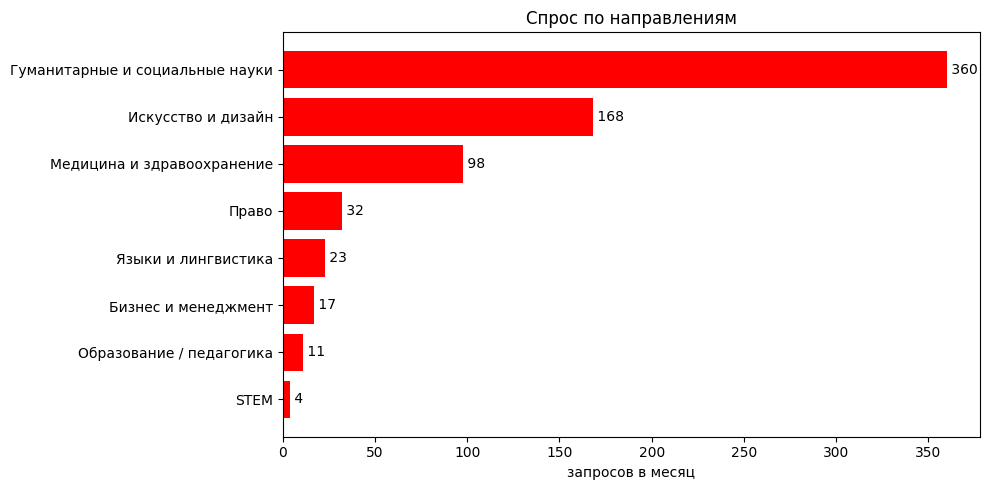

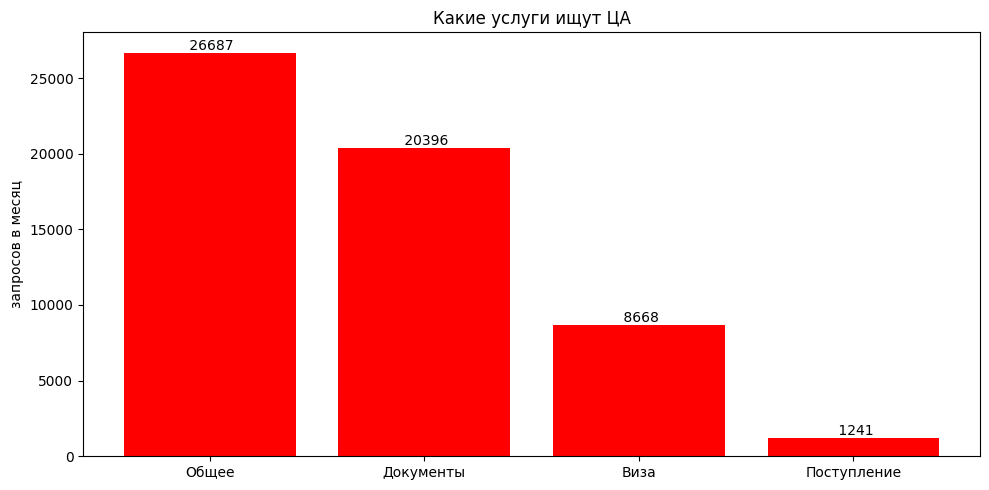

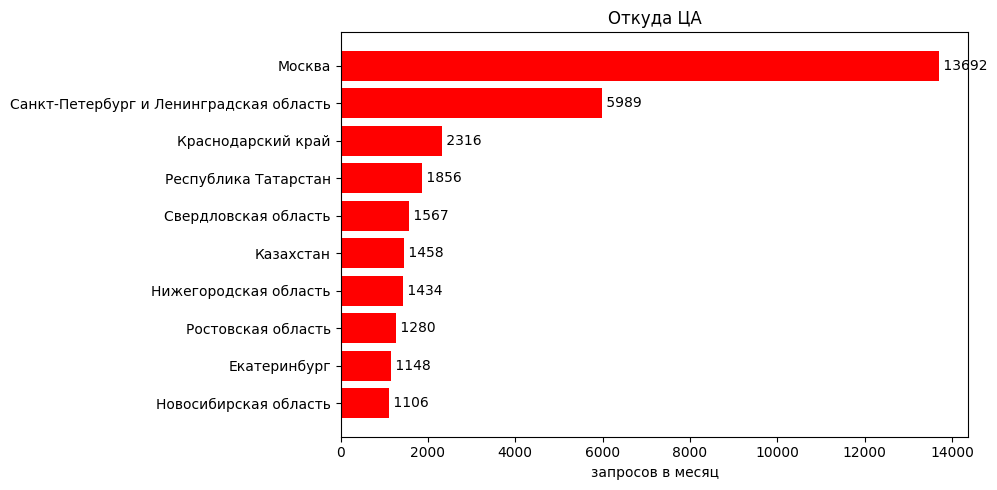

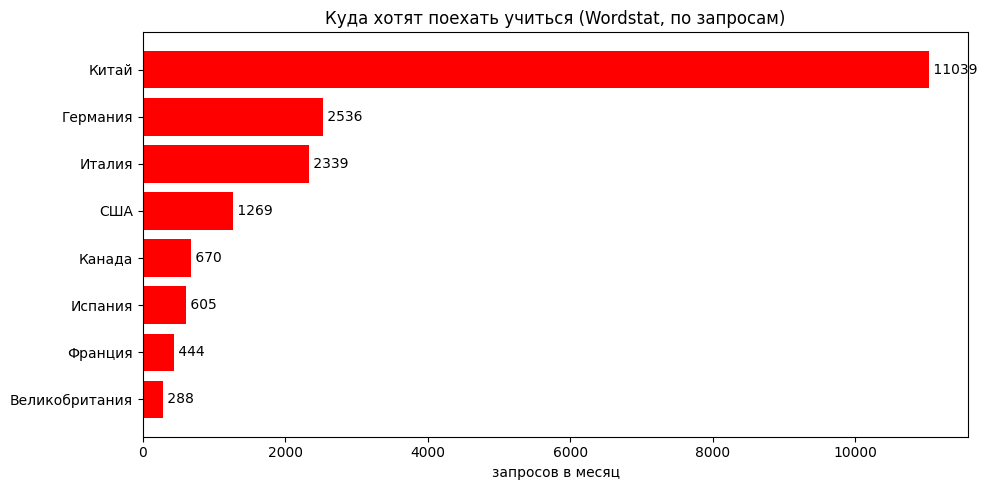

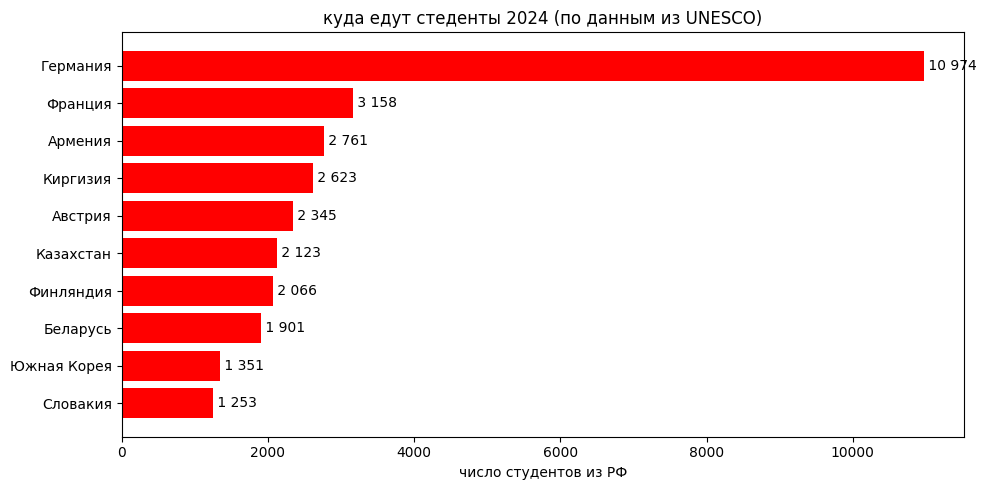

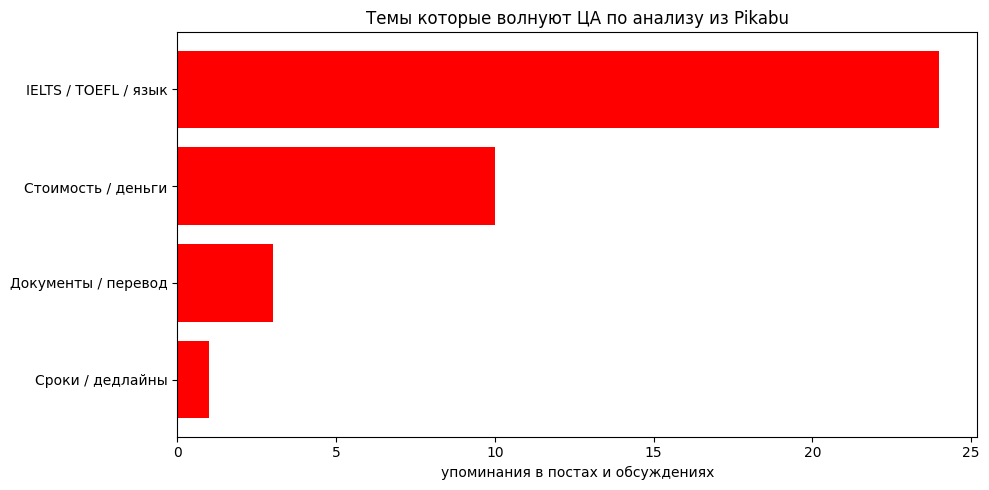

In [3]:
data = ProjectData()
report = AudienceAnalyzer(data)
report.full_report()

In [6]:
import os
import pandas as pd
import plotly.express as px


def run_dashboard(folder = "/content", output_file = "dashboard.html"):
    data = ProjectData(folder)
    analyzer = AudienceAnalyzer(data)

    figures = []

    # wordstat по направлениям

    df = data.wstat
    g = df.groupby("direction")["total_shows"].sum()
    g = g[g.index != "Не определено"]
    for d in DIRECTIONS_8:
        if d not in g.index:
            g[d] = 0
    g = g.sort_values(ascending=True)
    fig = px.bar(x = g.values, y = g.index, orientation = "h", title = "Спрос по направлениям")
    fig.update_layout(height = 400, xaxis_title = "запросов в месяц")
    figures.append(fig)

    # по услугам из вордстата

    g = data.wstat.groupby("service_type")["total_shows"].sum().sort_values(ascending = False)
    fig = px.pie(names = g.index, values = g.values, title = "Какие услуги ищут ЦА")
    fig.update_layout(height = 400)
    figures.append(fig)

    # вордстат по регионам откуда поиск

    real = data.regions[~data.regions["region"].isin(_AGGREGATES)]
    g = real.groupby("region")["shows"].sum().sort_values(ascending = False).head(10)
    g = g.sort_values(ascending=True)
    fig = px.bar(x = g.values, y = g.index, orientation = "h", title = "Откуда ЦА")
    fig.update_layout(height = 400, xaxis_title = "запросов в месяц")
    figures.append(fig)



    g = data.wordstat_countries.sort_values("total_shows", ascending=True)
    fig = px.bar(x = g["total_shows"], y = g["country"], orientation = "h", title = "Куда хотят поехать учиться (Wordstat)")
    fig.update_layout(height = 400, xaxis_title = "запросов в месяц")
    figures.append(fig)

    # Юнеско за 2024

    yr = 2024
    g = (data.unesco[data.unesco["year"] == yr].groupby("country")["students"].sum().sort_values(ascending = False).head(10))
    g = g.sort_values(ascending = True)
    fig = px.bar(x = g.values, y = g.index, orientation = "h", title = f"Куда едут студенты из РФ {yr} (по данным  изUNESCO)")
    fig.update_layout(height = 400, xaxis_title = "число студентов из РФ")
    figures.append(fig)

    # данные с пикабу
    if not data.forum.empty:
        keywords = {
            "Виза / отказ":         ["виза", "отказ", "консульств"],
            "Документы / перевод":  ["документ", "перевод", "апостиль", "нострификац"],
            "Стоимость / деньги":   ["дорого", "стоимость", "деньги", "бюджет"],
            "Стипендия / грант":    ["стипенди", "грант", "бесплатно"],
            "IELTS / TOEFL / язык": ["ielts", "toefl", "язык", "английск"],
            "Выбор вуза / страны":  ["какой вуз", "какую страну", "рейтинг"],
            "Сроки / дедлайны":     ["срок", "дедлайн", "не успе"],
            "Страх / непонятно":    ["сложно", "непонятно", "боюсь", "страшно"],
        }
        cols = [c for c in ["text", "title"] if c in data.forum.columns]
        all_text = " ".join(
            data.forum[cols].fillna("").astype(str).agg(" ".join, axis=1).str.lower()
        )
        counts = {k: sum(all_text.count(w) for w in ws) for k, ws in keywords.items()}
        top = {k: v for k, v in sorted(counts.items(), key=lambda x: -x[1]) if v > 0}
        if top:
            fig = px.bar(x = list(top.values()), y = list(top.keys()), orientation = "h", title = "Темы которые волнуют ЦА (Pikabu)")
            fig.update_layout(height = 400, xaxis_title = "упоминания в постах и обсуждениях")
            figures.append(fig)

    # сохраняю как html так как по другому у меня выводиться лишь пустота
    out_path = os.path.join(folder, output_file)
    with open(out_path, "w", encoding = "utf-8") as f:
        f.write("<html><head><meta charset='utf-8'>"
                "<script src='https://cdn.plot.ly/plotly-latest.min.js'></script>"
                "</head><body>")
        for fig in figures:
            f.write(fig.to_html(full_html = False, include_plotlyjs = False))
        f.write("</body></html>")

    for fig in figures:
        fig.show()

In [7]:
run_dashboard()

wordstat_by_query.csv - 27 строк
wordstat_by_region.csv - 6988 строк
unesco_students.csv - 1564 строк
selenium_pikabu.csv - 63 строк
wordstat_by_country.csv - 8 строк
